<a href="https://colab.research.google.com/github/Gowtham13042007/cron_job/blob/main/randomforestandxgboostipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn import tree

input_file='https://raw.githubusercontent.com/PacktPublishing/Hands-On-Data-Science-and-Python-Machine-Learning/master/PastHires.csv'
df=pd.read_csv(input_file)
df.head()

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,Y,4,BS,N,N,Y
1,0,N,0,BS,Y,Y,Y
2,7,N,6,BS,N,N,N
3,2,Y,1,MS,Y,N,Y
4,20,N,2,PhD,Y,N,N


In [ ]:
d={'Y':1,'N':0}
df['Hired']=df['Hired'].map(d)
df['Employed?']=df['Employed?'].map(d)
df['Top-tier school']=df['Top-tier school'].map(d)
df['Interned']=df['Interned'].map(d)
d={'BS':0,'MS':1,'PhD':2}
df['Level of Education']=df['Level of Education'].map(d)
df.head()

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,1,4,0,0,0,1
1,0,0,0,0,1,1,1
2,7,0,6,0,0,0,0
3,2,1,1,1,1,0,1
4,20,0,2,2,1,0,0


In [ ]:
features=list(df.columns[:6])
print(features)

['Years Experience', 'Employed?', 'Previous employers', 'Level of Education', 'Top-tier school', 'Interned']


In [ ]:
y=df['Hired']
x=df[features]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=100)
clf=tree.DecisionTreeClassifier()
clf=clf.fit(x_train,y_train)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
y_pred=clf.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.75


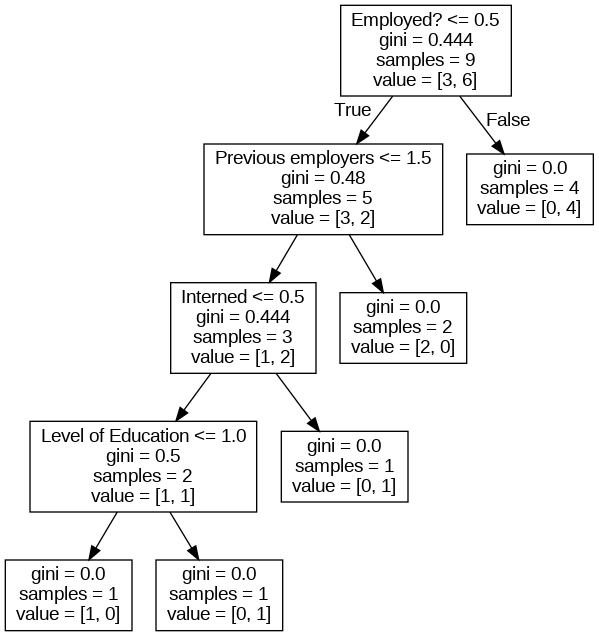

In [ ]:
from IPython.display import Image
from io import StringIO
import pydot
from sklearn import tree

dot_data = StringIO()

tree.export_graphviz(
    clf,
    out_file=dot_data,
    feature_names=features
)

graph = pydot.graph_from_dot_data(dot_data.getvalue())

Image(graph[0].create_png())

0.75
[1]
[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


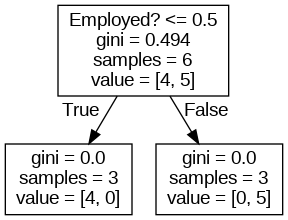

In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf=RandomForestClassifier(n_estimators=20)
clf=clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

print(clf.predict([[10,1,4,0,0,0]]))
print(clf.predict([[10,0,4,1,0,0]]))

from IPython.display import Image
from io import StringIO
import pydot
from sklearn import tree

dot_data = StringIO()

tree.export_graphviz(
    clf.estimators_[0],   # for random forest you need to check one tree at once
    out_file=dot_data,
    feature_names=features
)

graph = pydot.graph_from_dot_data(dot_data.getvalue())

Image(graph[0].create_png())

XgBoost

In [5]:
from sklearn.datasets import load_iris
iris=load_iris()
numSamples,numFeatures=iris.data.shape
print(numSamples,numFeatures)
print(iris.feature_names)
print(iris.target_names)

150 4
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(iris.data,iris.target,test_size=0.2,random_state=0)

In [7]:
import xgboost as xgb
train=xgb.DMatrix(x_train,label=y_train)
test=xgb.DMatrix(x_test,label=y_test)    #convert data into DMatrix

In [13]:
parm={
    'max_depth':10,   # max length must be 4
    'eta':0.1,       # learning_rate
    'objective':'multi:softmax',  #probability assigned for each class
    'num_class':3        #3 output classes
}
epochs=10  #boosting trees sequentially


In [14]:
model=xgb.train(parm,train,epochs)


In [15]:
predictions=model.predict(test)
print(predictions)

[2. 1. 0. 2. 0. 2. 0. 1. 1. 1. 2. 1. 1. 1. 1. 0. 1. 1. 0. 0. 2. 1. 0. 0.
 2. 0. 0. 1. 1. 0.]


In [16]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,predictions)

1.0